In [1]:
import pandas as pd
import numpy as np
from scipy import stats  # This is the "science" library for the test
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Marketing-Campaign.csv')

# Check the first few rows to ensure column names like 'Promotion' and 'SalesInThousands' are correct
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


Null Hypothesis ($H_0$): There is no significant difference in sales between Promotion 1 and Promotion 2.
Alternative Hypothesis ($H_1$): There is a significant difference in sales between the two promotions.
Alpha ($\alpha$): We set our limit to 0.05. If our result (p-value) is smaller than this, it's "proof" that one promotion is better

In [3]:
# Split the data into two groups based on the 'Promotion' column
group_1 = df[df['Promotion'] == 1]['SalesInThousands']
group_2 = df[df['Promotion'] == 2]['SalesInThousands']

# Calculate the averages
print(f"Mean Sales for Promotion 1: {group_1.mean():.2f}")
print(f"Mean Sales for Promotion 2: {group_2.mean():.2f}")

Mean Sales for Promotion 1: 58.10
Mean Sales for Promotion 2: 47.33


In [4]:
# Run the t-test
t_stat, p_value = stats.ttest_ind(group_1, group_2)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Final decision logic
if p_value < 0.05:
    print("Result: Statistically Significant. Reject the Null Hypothesis.")
else:
    print("Result: Not Significant. Fail to reject the Null Hypothesis.")

T-Statistic: 6.4537
P-Value: 0.0000
Result: Statistically Significant. Reject the Null Hypothesis.


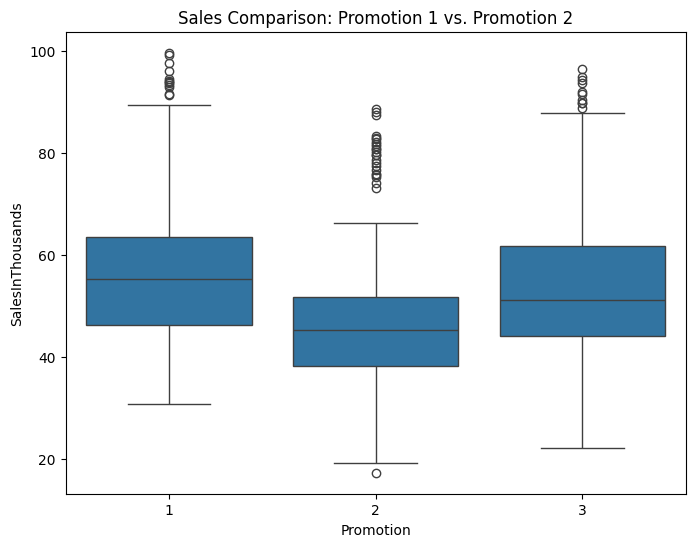

In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Promotion', y='SalesInThousands', data=df)
plt.title('Sales Comparison: Promotion 1 vs. Promotion 2')
plt.show()